In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

matches = pd.read_csv('datasets/KaggleMatches.csv',low_memory=False)


In [12]:
# these dont seem relevant to my analysis
removed_columns = ['match_num','tourney_id','winner_seed','winner_id','loser_id','loser_seed','loser_entry','winner_entry']

for i in removed_columns:
    matches.drop(i,axis =1,inplace=True)

# Convert numerical values to float
numeric_columns = ['w_ace', 'l_ace', 'w_df', 'l_df', 'w_bpSaved', 'l_bpSaved', 'winner_rank', 'loser_rank', 'winner_age', 'loser_age', 'winner_ht', 'loser_ht', 'w_svpt', 'l_svpt', 'minutes']
matches[numeric_columns] = matches[numeric_columns].astype(float)

#removing all the other surfaces except the major ones
surfaces = ['Hard','Clay','Grass']
matches = matches[matches['surface'].isin(surfaces)]

# matches['draw_size'] = pd.to_numeric(matches['draw_size'],errors="coerce")
levels = ['G','M','C','F'] #selected only the most significant tournaments(according to me) ie grandslams, masters, challengers and futures
matches = matches[matches['tourney_level'].isin(levels)]

In [13]:
# Define the function to extract date features
def extract_date_features(df, date_column):
    # Convert the date column to datetime format if needed
    if not pd.api.types.is_datetime64_any_dtype(df[date_column]):
        df[date_column] = pd.to_datetime(df[date_column])

    # Extract year, month, and day
    df['tourney_year'] = df[date_column].dt.year
    df['tourney_month'] = df[date_column].dt.month

    df['tourney_quarter'] = df[date_column].dt.quarter
    return df


# Define the date column
date_column = 'tourney_date'

# Extract date features from the train dataset
matches = extract_date_features(matches, date_column)
matches.drop('tourney_date',axis =1,inplace=True)

In [14]:
def rename_columns(col):
    '''This function renames the dataframe column title'''
    if col.startswith('tourney_'):
           col = 't_' + ''.join(col.split('_')[1:])
           return col 
    elif col.startswith('loser_'):
             col = 'l_' + ''.join(col.split('_')[1:])
             return col 
    elif col.startswith("winner_"):
              col = "w_" + ''.join(col.split('_')[1:])
              return  col
    else:
       return col

matches.rename(columns=rename_columns,  inplace=True)

## Novak Djokovic

In [15]:
player_name = "Novak Djokovic"
matches = matches[(matches['w_name'] == player_name) | (matches['l_name'] == player_name)].reset_index()
matches['win'] = np.where(matches['w_name'] == player_name,1,0)

In [16]:
overall_surface = matches.groupby(['surface']).agg({'t_name':'count','w_rank':'mean','l_rank':'mean','win':'sum','w_rankpoints':'mean','l_rankpoints':'mean','w_df':'mean','w_ace':'mean','w_svpt':'mean','w_1stIn':'mean','w_1stWon':'mean'\
                                  ,'w_2ndWon':'mean','w_SvGms':'mean','w_bpSaved':'mean','w_bpFaced':'mean'\
                                    ,'l_df':'mean','l_ace':'mean','l_svpt':'mean','l_1stIn':'mean','l_1stWon':'mean'\
                                        ,'l_2ndWon':'mean','l_SvGms':'mean','l_bpSaved':'mean','l_bpFaced':'mean'}).fillna(0)

In [17]:
overall_surface.rename(columns={'t_name':'matches_played','win':'matches_won'},  inplace=True)
overall_surface['w_pct'] =overall_surface['matches_won'] / overall_surface['matches_played']
overall_surface[['matches_played','matches_won','w_pct']].sort_values(by=['matches_played','w_pct'],ascending = False)

,matches_played,matches_won,w_pct
surface,,,
Hard,532,446,0.838346
Clay,237,194,0.818565
Grass,82,72,0.878049


In [18]:
#calculate the average perfromance for player in his first year
def surfaces_average(df):
    
    x = df.groupby(['surface']).agg({'t_name':'count','win':'sum'})
    x['w_pct'] =x['win'] / x['t_name']
    x.rename(columns={'t_name':'matches_played','win':'matches_won'},  inplace=True)
    return x[['matches_played','matches_won','w_pct']].sort_values(by=['matches_played','w_pct'],ascending = False)

surfaces_average(matches[matches['t_year'] == 2005])
surfaces_average(matches[matches['t_year'] == 2019])

,matches_played,matches_won,w_pct
surface,,,
Hard,31,24,0.774194
Clay,19,16,0.842105
Grass,7,7,1.000000


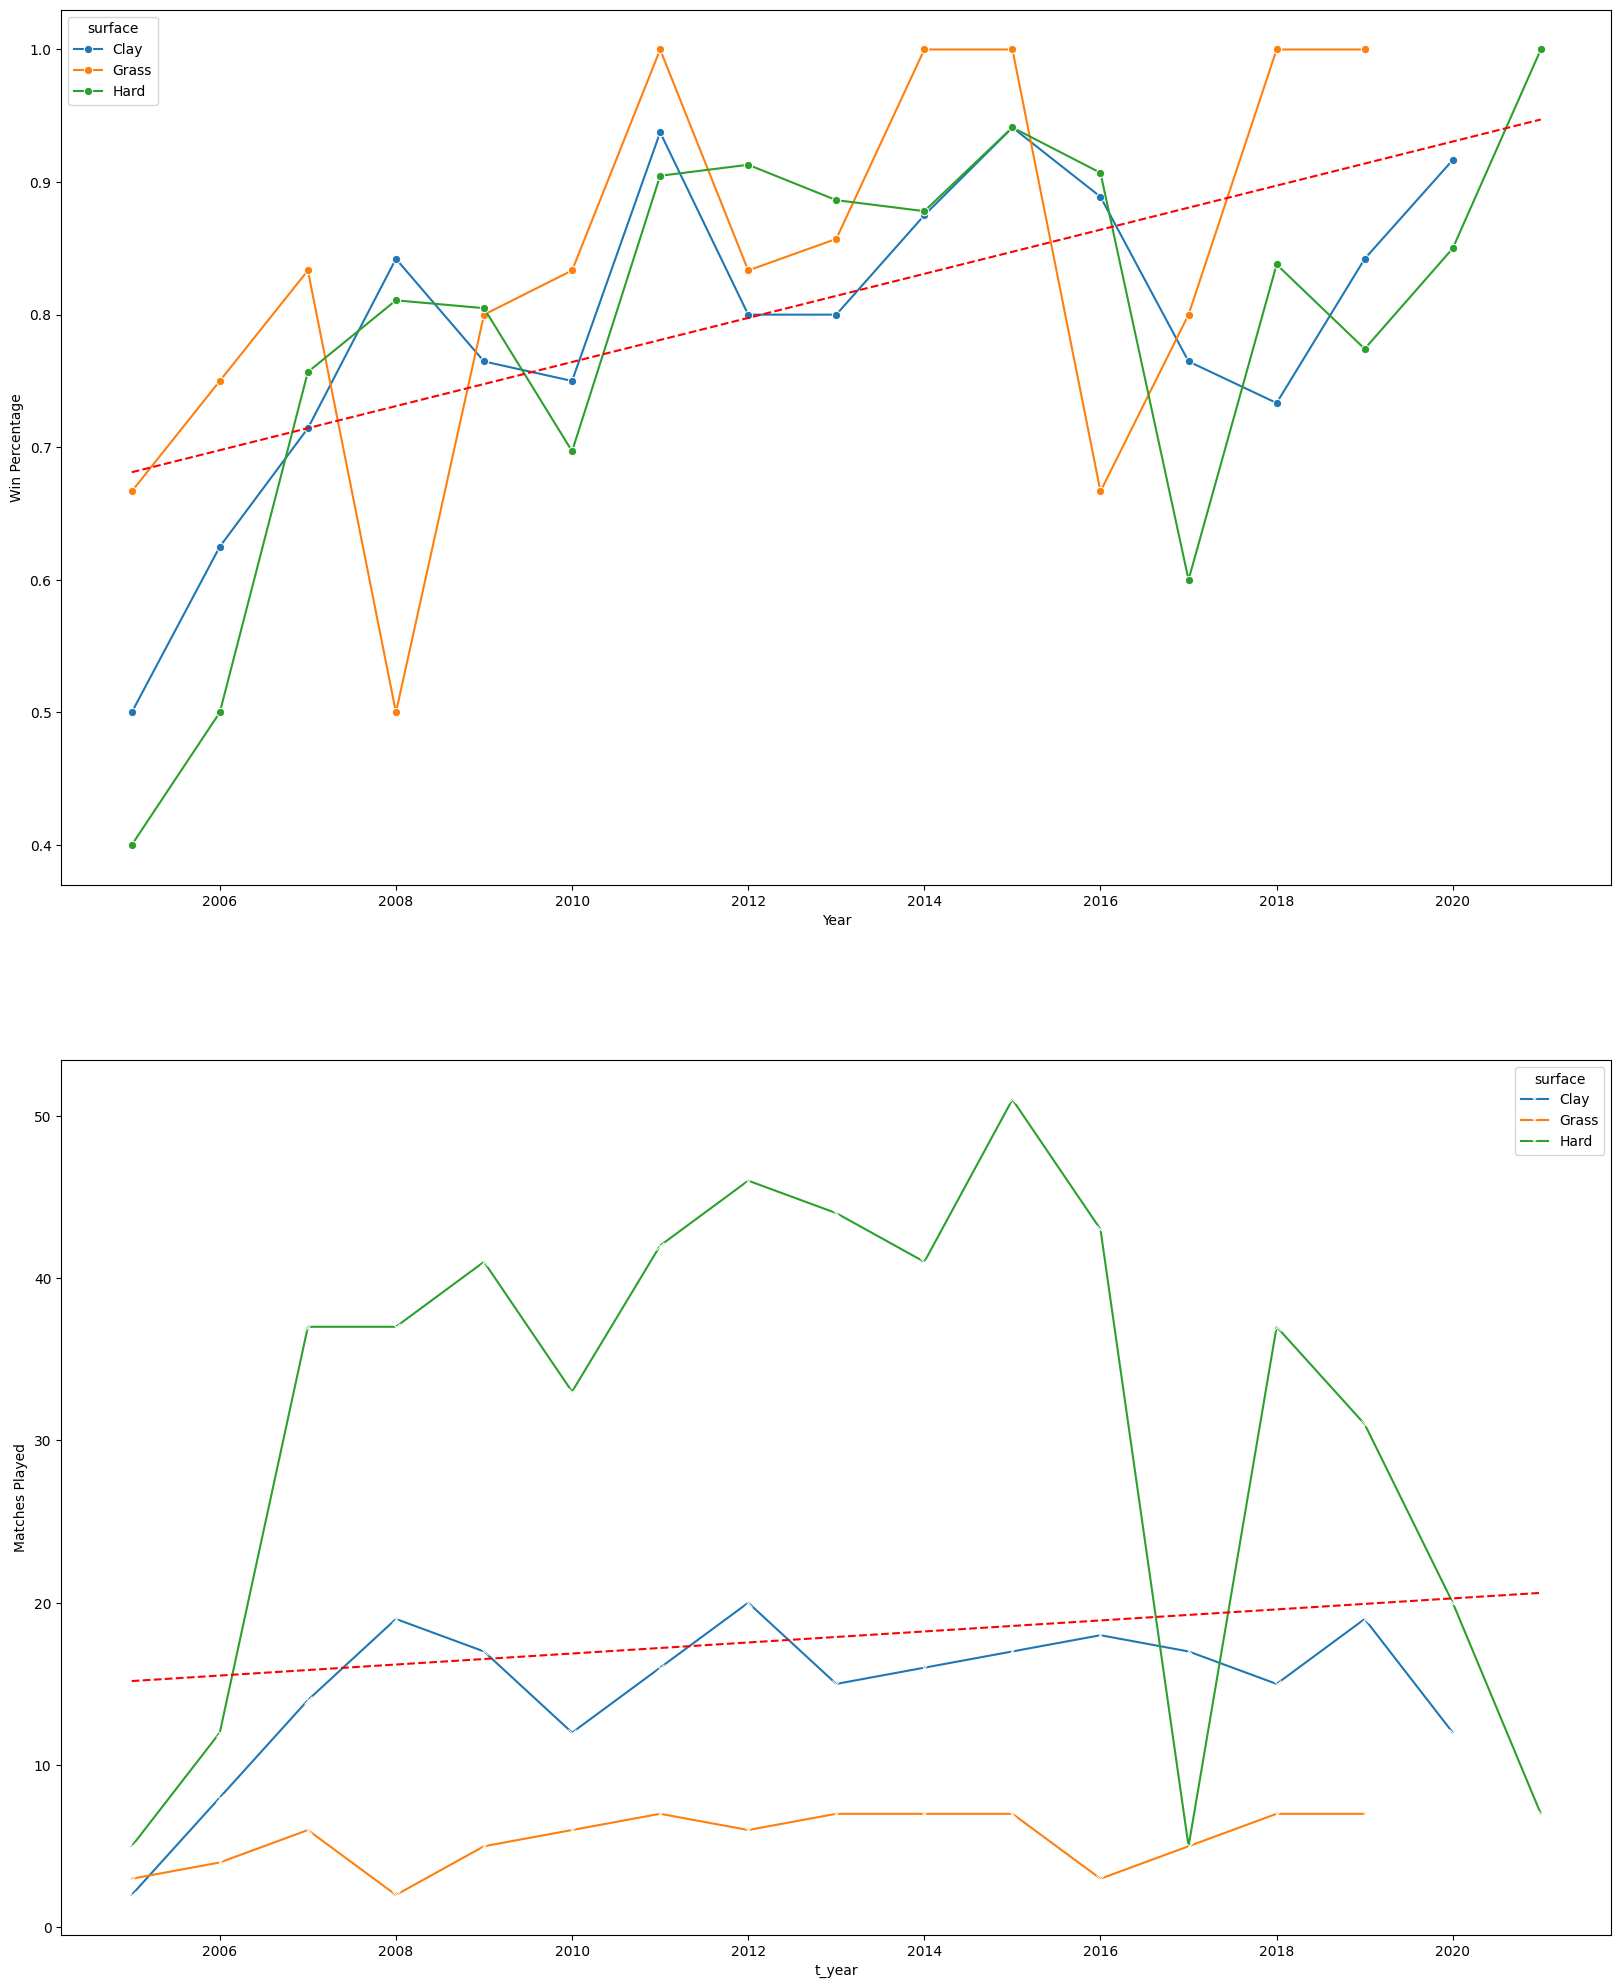

In [19]:
yearly_performance = matches.groupby(['t_year','surface']).agg({'t_name':'count','win':'sum'}).reset_index()
yearly_performance['w_pct'] =yearly_performance['win'] / yearly_performance['t_name']
yearly_performance.rename(columns={'t_name':'matches_played','win':'matches_won'},  inplace=True)

fig = plt.figure(figsize=(20,25))

ax1 = fig.add_subplot(211)
ax1 = sns.lineplot(data=yearly_performance, x='t_year', y='w_pct',hue='surface', marker='o', ax=ax1, color='b')
ax1.set_xlabel('Year')
ax1.set_ylabel('Win Percentage')

# Fit a linear model to the data and plot the trend line
z = np.polyfit(yearly_performance['t_year'], yearly_performance['w_pct'], 1)
p = np.poly1d(z)
plt.plot(yearly_performance['t_year'], p(yearly_performance['t_year']), "r--")


ax2 = fig.add_subplot(212)
ax2 = sns.lineplot(data=yearly_performance, x='t_year', y='matches_played' ,hue='surface', marker='x', ax=ax2, color='r')
ax2.set_ylabel('Matches Played')

# Fit a linear model to the data and plot the trend line
z = np.polyfit(yearly_performance['t_year'], yearly_performance['matches_played'], 1)
p = np.poly1d(z)
plt.plot(yearly_performance['t_year'], p(yearly_performance['t_year']), "r--")


C:\Users\user\AppData\Local\Temp\ipykernel_11576\569399153.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90);
C:\Users\user\AppData\Local\Temp\ipykernel_11576\569399153.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90);


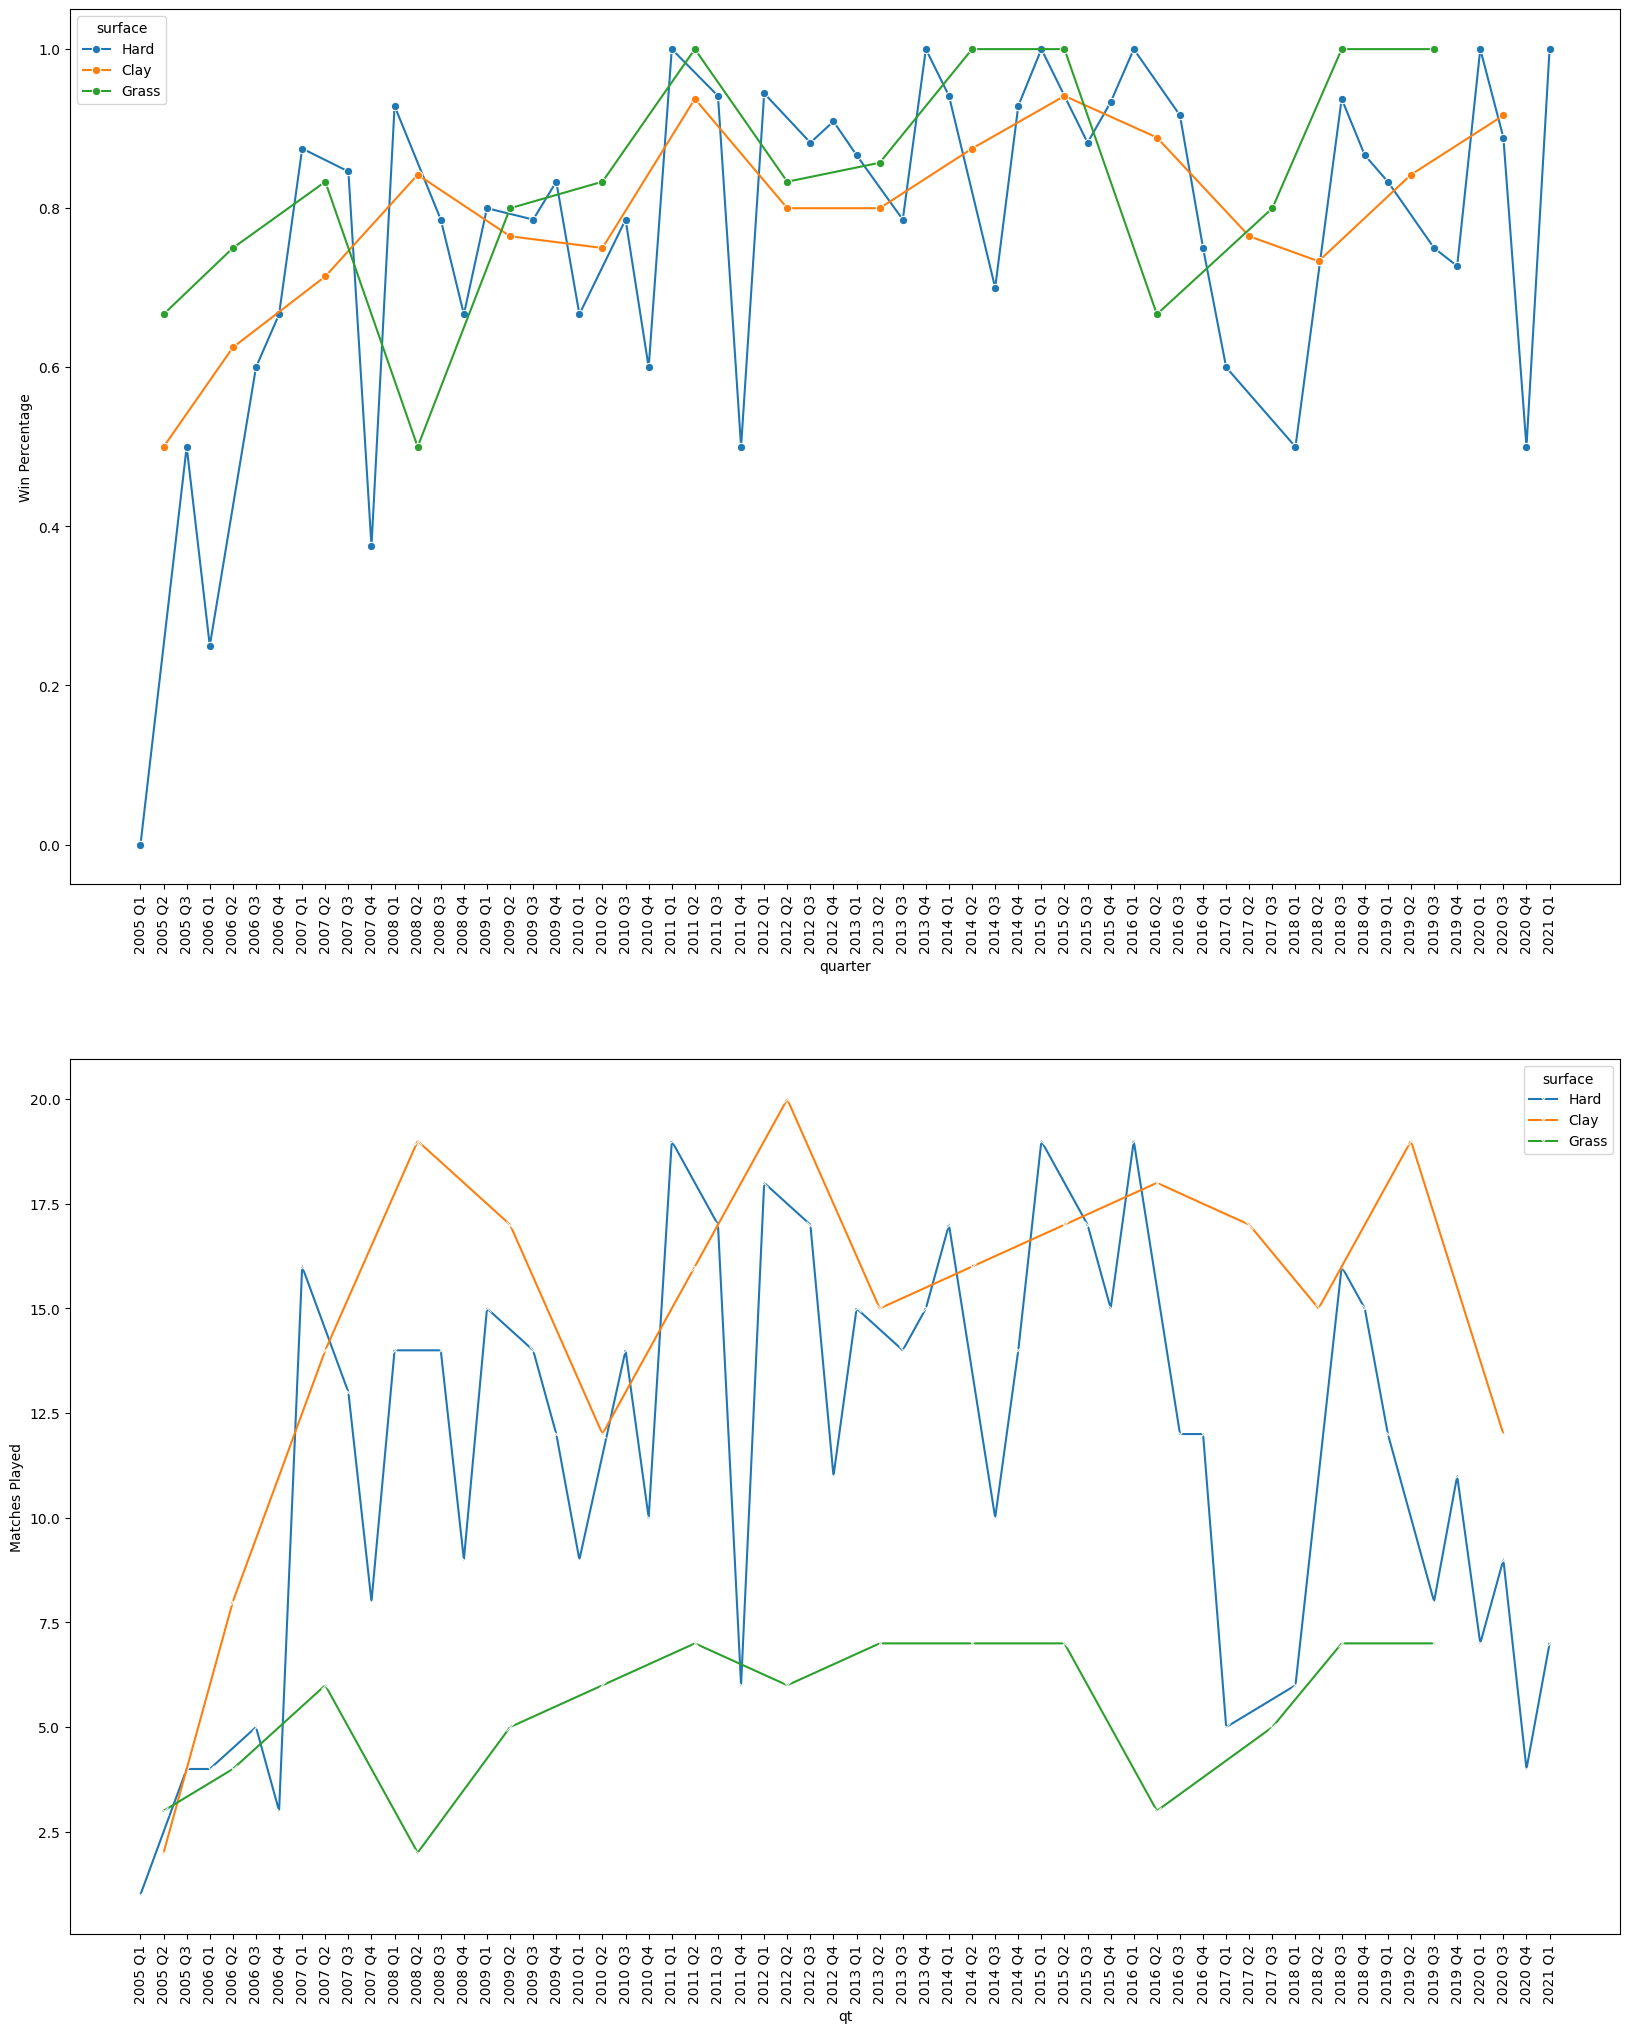

In [20]:

quarterly_performance = matches.groupby(['t_year','t_quarter','surface']).agg({'t_name':'count','win':'sum'}).reset_index()
quarterly_performance['w_pct'] =quarterly_performance['win'] / quarterly_performance['t_name']
quarterly_performance.rename(columns={'t_name':'matches_played','win':'matches_won'},  inplace=True)
quarterly_performance[['t_year','t_quarter']] = quarterly_performance[['t_year','t_quarter']].astype(str)
quarterly_performance['qt'] = quarterly_performance['t_year'] + ' Q'+quarterly_performance['t_quarter']
quarterly_performance.drop(columns=['t_year','t_quarter'],inplace=True)

fig = plt.figure(figsize=(20,25))


ax1 = fig.add_subplot(211)
ax1 = sns.lineplot(data=quarterly_performance, x='qt', y='w_pct',hue='surface', marker='o', ax=ax1, color='b')
ax1.set_ylabel('Win Percentage')
ax1.set_xlabel('quarter')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90);

ax2 = fig.add_subplot(212)
ax2 = sns.lineplot(data=quarterly_performance, x='qt', y='matches_played' ,hue='surface', marker='x', ax=ax2, color='r')
ax2.set_ylabel('Matches Played')
ax1.set_xlabel('quarter')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90);

